In [ ]:
!pip install timm scikit-learn pandas matplotlib --quiet

import os, zipfile
from glob import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    balanced_accuracy_score,
    cohen_kappa_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

import timm

# ----- Matplotlib: bold, dark, big -----
plt.rcParams.update({
    "font.size": 14,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.edgecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
})

In [ ]:
import subprocess, torch, platform, psutil

def run(cmd):
    return subprocess.getoutput(cmd)

print("===== OS =====")
print(platform.platform())

print("\n===== CPU =====")
print(run("lscpu | egrep 'Model name|Socket|Thread|Core|CPU\\(s\\)|MHz|Vendor ID'"))

print("\n===== RAM =====")
print(run("free -h"))

print("\n===== GPU =====")
print(run("nvidia-smi -L"))
print(run("nvidia-smi --query-gpu=name,memory.total,driver_version --format=csv,noheader"))

print("\n===== CUDA =====")
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Torch CUDA version:", torch.version.cuda)

print("\n===== STORAGE =====")
print(run("df -h /"))


===== OS =====
Linux-6.6.105+-x86_64-with-glibc2.35

===== CPU =====
CPU(s):                                  12
On-line CPU(s) list:                     0-11
Vendor ID:                               GenuineIntel
Model name:                              Intel(R) Xeon(R) CPU @ 2.20GHz
Thread(s) per core:                      2
Core(s) per socket:                      6
Socket(s):                               1
NUMA node0 CPU(s):                       0-11

===== RAM =====
               total        used        free      shared  buff/cache   available
Mem:            83Gi       1.6Gi        77Gi       3.0Mi       4.1Gi        81Gi
Swap:             0B          0B          0B

===== GPU =====
GPU 0: NVIDIA A100-SXM4-40GB (UUID: GPU-9e5596e2-8a3e-b083-f255-189f3fec5bfb)
NVIDIA A100-SXM4-40GB, 40960 MiB, 550.54.15

===== CUDA =====
Torch: 2.9.0+cu126
CUDA available: True
Torch CUDA version: 12.6

===== STORAGE =====
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   3

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from copy import deepcopy
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ZIP_PATH_IN_DRIVE = "/content/drive/MyDrive/Augmented_Dataset_Split.zip"  # <-- change
EXTRACT_DIR       = "/content"

os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH_IN_DRIVE, 'r') as z:
    z.extractall(EXTRACT_DIR)

print("Extracted to:", EXTRACT_DIR)
print("Top level:", os.listdir(EXTRACT_DIR))

Mounted at /content/drive
Extracted to: /content/dataset
Top level: ['Augmented Dataset Split']


In [ ]:
import shutil

path = "/content/dataset/Augmented_Dataset_Split/.ipynb_checkpoints"

try:
    shutil.rmtree(path)
    print("Deleted:", path)
except FileNotFoundError:
    print("Folder not found!")
except Exception as e:
    print("Error:", e)

Deleted: /content/dataset/Augmented_Dataset_Split/.ipynb_checkpoints


In [ ]:
class MultiSplitImageDataset(Dataset):
    def __init__(self, root_dir, split="train", transform=None):
        self.root_dir = root_dir
        self.split = split
        self.transform = transform

        # class folders
        self.class_names = sorted([
            d for d in os.listdir(root_dir)
            if os.path.isdir(os.path.join(root_dir, d))
        ])
        self.class_to_idx = {c: i for i, c in enumerate(self.class_names)}
        self.idx_to_class = {i: c for c, i in self.class_to_idx.items()}

        self.samples = []
        valid_exts = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

        for cls_name in self.class_names:
            split_folder = os.path.join(root_dir, cls_name, self.split)

            if not os.path.isdir(split_folder):
                print(f"[WARN] No '{self.split}' folder in {cls_name}")
                continue

            # ✅ fixed file scan (no glob, works with brackets)
            for fname in os.listdir(split_folder):
                if fname.lower().endswith(valid_exts):
                    fpath = os.path.join(split_folder, fname)
                    self.samples.append((fpath, self.class_to_idx[cls_name]))

        print(f"[{self.split}] {len(self.samples)} images, {len(self.class_names)} classes.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fpath, label = self.samples[idx]
        img = Image.open(fpath).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


In [ ]:
IMG_SIZE = 256

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

# ✅ train uses SAME transform now
train_transform = val_test_transform



In [ ]:
# ✅ Define DATASET_ROOT first
DATASET_ROOT = "/content/Augmented_Dataset_Split/Augmented_Dataset"

# ✅ Load datasets again
full_train_dataset = MultiSplitImageDataset(DATASET_ROOT, "train", train_transform)
test_dataset       = MultiSplitImageDataset(DATASET_ROOT, "test",  val_test_transform)

print("Train samples:", len(full_train_dataset))
print("Test samples:", len(test_dataset))


[train] 16242 images, 10 classes.
[test] 809 images, 10 classes.
Train samples: 16242
Test samples: 809


In [ ]:
from torch.utils.data import random_split

val_ratio = 0.2
train_size = int(len(full_train_dataset) * (1 - val_ratio))
val_size   = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print("Train split:", len(train_dataset))
print("Val split:", len(val_dataset))


Train split: 12993
Val split: 3249


In [ ]:
NUM_CLASSES = len(full_train_dataset.class_names)
print("NUM_CLASSES =", NUM_CLASSES)

NUM_CLASSES = 10


In [ ]:
full_train_dataset.class_names

['Central Serous Chorioretinopathy [Color Fundus]',
 'Diabetic Retinopathy',
 'Disc Edema',
 'Glaucoma',
 'Healthy',
 'Macular Scar',
 'Myopia',
 'Pterygium',
 'Retinal Detachment',
 'Retinitis Pigmentosa']

In [ ]:
import torch

# ✅ define device BEFORE using it
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [ ]:
# ✅ Swin Transformer V2 Small with dropout 0.3
model = timm.create_model(
    "swinv2_small_window16_256",
    pretrained=True,
    num_classes=NUM_CLASSES,
    drop_rate=0.3               # ✅ added dropout
)

model.to(device)

print("Trainable parameters:",
      sum(p.numel() for p in model.parameters() if p.requires_grad))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/204M [00:00<?, ?B/s]

Trainable parameters: 48967108


In [ ]:
# # Class counts from the original full_train_dataset
# class_counts = np.zeros(NUM_CLASSES, dtype=np.int64)
# for _, label in val_dataset.samples:
#     class_counts[label] += 1

# print("Class counts:", class_counts)

# # Safe inverse-frequency weights
# safe_counts = np.where(class_counts == 0, 1, class_counts)
# class_weights = 1.0 / safe_counts
# class_weights = class_weights / class_weights.sum() * NUM_CLASSES

# class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
# print("Class weights:", class_weights)


AttributeError: 'Subset' object has no attribute 'samples'

Class counts: [606 981 762 900 900 900 900 100 750 832]
Class weights: [0.78723351 0.48630327 0.62606759 0.53007056 0.53007056 0.53007056
 0.53007056 4.77063506 0.63608468 0.57339364]

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce = nn.functional.cross_entropy(logits, targets, reduction="none")
        pt = torch.exp(-ce)
        loss = (1 - pt) ** self.gamma * ce

        if self.alpha is not None:
            loss = self.alpha[targets] * loss

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        else:
            return loss

In [ ]:
def get_loss_fn(loss_type="combined", alpha_w=0.5):

    # Cross entropy with label smoothing only
    ce = nn.CrossEntropyLoss(
        label_smoothing=0.1
    )

    # Focal loss without class weights
    focal = FocalLoss(
        alpha=None,   # removed weights
        gamma=2.0
    )

    if loss_type == "ce":
        return ce
    elif loss_type == "focal":
        return focal
    elif loss_type == "combined":
        def combined(logits, targets):
            return alpha_w * ce(logits, targets) + (1 - alpha_w) * focal(logits, targets)
        return combined
    else:
        raise ValueError("Invalid loss_type")


LOSS_TYPE = "combined"
loss_fn = get_loss_fn(LOSS_TYPE, alpha_w=0.5)


In [ ]:
EPOCHS = 20                    # ✅ train only 40 epochs now
LR = 3e-5                     # ✅ new learning rate
WEIGHT_DECAY = 1e-3           # ✅ updated from 0.0001
WARMUP_EPOCHS = 4

optimizer = optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)


criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.1)  # optional but nice

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',       # we want to minimize val_loss
    factor=0.5,       # LR = LR * 0.5 when plateau
    patience=3,       # epochs to wait without improvement
    min_lr=1e-7
)

# warmup_epochs = 5

# # ✅ Apply warm-up then cosine decay
# def lr_lambda(current_epoch):
#     if current_epoch < warmup_epochs:
#         return float(current_epoch) / float(max(1, warmup_epochs))
#     return 0.5 * (1 + np.cos(np.pi * (current_epoch - warmup_epochs) / (EPOCHS - warmup_epochs)))

# scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 16
NUM_WORKERS = 2   # Set to 0 if running on CPU

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("✅ DataLoaders ready!")


✅ DataLoaders ready!


In [ ]:
def warmup_lr(epoch):
    """Linear warmup scaling factor."""
    return (epoch + 1) / WARMUP_EPOCHS


In [ ]:
best_val_loss = float('inf')

for epoch in range(EPOCHS):

    # ---- TRAIN ----
    model.train()
    running_train_loss = 0
    correct_train, total_train = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    train_loss = running_train_loss / total_train
    train_acc = correct_train / total_train


    # ---- VALIDATION ----
    model.eval()
    running_val_loss = 0
    correct_val, total_val = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    val_loss = running_val_loss / total_val
    val_acc = correct_val / total_val


    # ---- LR UPDATE ----
    if epoch < WARMUP_EPOCHS:
        # Apply warmup scaling
        scale = warmup_lr(epoch)
        optimizer.param_groups[0]["lr"] = LR * scale
    else:
        scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]


    # ---- SAVE BEST MODEL ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pth")
        print(f"🔥 New best saved at epoch {epoch+1} | Val Loss: {val_loss:.4f}")


    # ---- LOG ----
    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} val Acc: {val_acc:.4f} | "
        f"LR: {current_lr:.8f}"
    )


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


In [ ]:
from copy import deepcopy
import torch

def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def eval_epoch(model, loader, loss_fn, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            loss = loss_fn(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_labels.append(labels.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    all_labels = np.concatenate(all_labels)
    all_preds  = np.concatenate(all_preds)
    all_probs  = np.concatenate(all_probs)

    return running_loss / total, correct / total, all_labels, all_preds, all_probs


In [ ]:
history = { "train_loss": [], "val_loss": [],
            "train_acc":  [], "val_acc":  [] }

best_val_loss = float("inf")
best_wts = deepcopy(model.state_dict())

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
    val_loss, val_acc, _, _, _ = eval_epoch(model, val_loader, loss_fn, device)

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] "
          f"(✅ {epoch+1} completed) | "
          f"Train Loss: {train_loss:.4f} Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Val Acc: {val_acc:.4f}")

    # ✅ now saving based on lowest val loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_wts = deepcopy(model.state_dict())
        torch.save(best_wts, "best_swinv2_small.pth")
        print("  ✅ New best model saved (based on val loss).")

model.load_state_dict(best_wts)
print("\n🎯 Training complete!")


ValueError: x and y must have same first dimension, but have shapes (40,) and (23,)

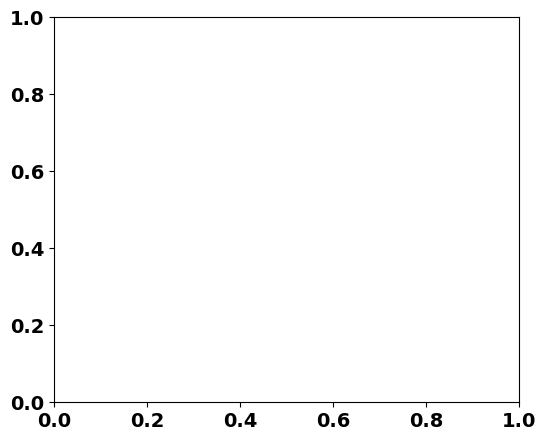

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 14,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.edgecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
})

epochs = np.arange(1, EPOCHS + 1)

# Accuracy
plt.figure(figsize=(6, 5))
plt.plot(epochs, history["train_acc"], label="Train Accuracy", linewidth=2)
plt.plot(epochs, history["val_acc"],   label="Val Accuracy",   linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy")
plt.legend()
plt.grid(True, linewidth=0.5)
plt.tight_layout()
plt.savefig("accuracy_curve_600dpi.png", dpi=600, bbox_inches="tight")
plt.show()

# Loss
plt.figure(figsize=(6, 5))
plt.plot(epochs, history["train_loss"], label="Train Loss", linewidth=2)
plt.plot(epochs, history["val_loss"],   label="Val Loss",   linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid(True, linewidth=0.5)
plt.tight_layout()
plt.savefig("loss_curve_600dpi.png", dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    balanced_accuracy_score,
    cohen_kappa_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize
import pandas as pd


In [ ]:
test_loss, test_acc, y_true, y_pred, y_prob = eval_epoch(model, test_loader, loss_fn, device)
print(f"\nTest Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

cm = confusion_matrix(y_true, y_pred)
S = cm.sum()
n_i = cm.sum(axis=1)
N  = NUM_CLASSES

TP = np.diag(cm)
FN = cm.sum(axis=1) - TP
FP = cm.sum(axis=0) - TP
TN = S - (TP + FN + FP)



Test Loss: 0.9780 | Test Accuracy: 0.7256


In [ ]:
# per-class metrics
acc_i  = (TP + TN) / (TP + TN + FP + FN + 1e-8)
tpr_i  = TP / (TP + FN + 1e-8)   # sensitivity
tnr_i  = TN / (TN + FP + 1e-8)   # specificity
ppv_i  = TP / (TP + FP + 1e-8)
npv_i  = TN / (TN + FN + 1e-8)
f1_i   = 2 * ppv_i * tpr_i / (ppv_i + tpr_i + 1e-8)
balacc_i = (tpr_i + tnr_i) / 2

# kappa per class (one-vs-rest)
kappa_i = []
for c in range(N):
    tp, tn, fp, fn = TP[c], TN[c], FP[c], FN[c]
    po = (tp + tn) / (tp + tn + fp + fn + 1e-8)
    p_yes_true = (tp + fn) / S
    p_yes_pred = (tp + fp) / S
    p_no_true  = 1 - p_yes_true
    p_no_pred  = 1 - p_yes_pred
    pe = p_yes_true * p_yes_pred + p_no_true * p_no_pred
    kappa = (po - pe) / (1 - pe + 1e-8)
    kappa_i.append(kappa)
kappa_i = np.array(kappa_i)

# mean true-class confidence
class_conf = []
for c in range(N):
    idx_c = np.where(y_true == c)[0]
    if len(idx_c) == 0:
        class_conf.append(np.nan)
    else:
        class_conf.append(y_prob[idx_c, c].mean() * 100.0)

class_names = full_train_dataset.class_names  # original class names

per_class_df = pd.DataFrame({
    "Class": class_names,
    "Acc.": acc_i * 100,
    "Bal. Acc.": balacc_i * 100,
    "TPR": tpr_i * 100,
    "TNR": tnr_i * 100,
    "PPV": ppv_i * 100,
    "NPV": npv_i * 100,
    "F1-Score": f1_i * 100,
    "Kappa": kappa_i * 100,
    "Confidence Score": class_conf
})

pd.set_option("display.max_rows", None)
display(per_class_df)

per_class_df.to_csv("per_class_metrics_table.csv", index=False)
print("Saved per-class metrics to per_class_metrics_table.csv")


,Class,Acc.,Bal. Acc.,TPR,TNR,PPV,NPV,F1-Score,Kappa,Confidence Score
0,Central Serous Chorioretinopathy,99.258344,99.621690,100.000000,99.243380,72.727273,100.000000,84.210526,83.840450,87.942955
1,Diabetic Retinopathy,94.808405,93.321028,89.912281,96.729776,91.517857,96.068376,90.707964,87.106296,72.825172
2,Disc Edema,98.887515,97.111433,95.238095,98.984772,71.428571,99.871959,81.632653,81.071090,83.492691
3,Glaucoma,81.458591,71.845325,52.450980,91.239669,66.875000,85.053929,58.791208,47.054048,43.848083
4,Healthy,90.976514,85.487261,76.623377,94.351145,76.129032,94.495413,76.375404,70.798698,64.290054
5,Macular Scar,93.201483,75.927304,55.223881,96.630728,59.677419,95.983936,57.364341,53.676612,42.725281
6,Myopia,88.009889,73.041780,54.666667,91.416894,39.423077,95.177305,45.810055,39.267553,46.598724
7,Pterygium,99.876391,99.938118,99.999999,99.876238,50.000000,100.000000,66.666666,66.611458,99.192787
8,Retinal Detachment,99.629172,97.373257,95.000000,99.746515,90.476190,99.873096,92.682926,92.492790,84.591377
9,Retinitis Pigmentosa,99.011125,99.491094,100.000000,98.982188,74.193548,100.000000,85.185185,84.685268,87.110100


Saved per-class metrics to per_class_metrics_table.csv


In [ ]:
weights = n_i / S

TPR_global = np.sum(weights * tpr_i)
TNR_global = np.sum(weights * tnr_i)
PPV_global = np.sum(weights * ppv_i)
NPV_global = np.sum(weights * npv_i)
F1_global  = np.sum(weights * f1_i)

bal_acc_global = balanced_accuracy_score(y_true, y_pred)
kappa_global   = cohen_kappa_score(y_true, y_pred)

print("\n=== Global metrics ===")
print(f"Accuracy:           {test_acc*100:.2f}")
print(f"Balanced Accuracy:  {bal_acc_global*100:.2f}")
print(f"TPR (weighted):     {TPR_global*100:.2f}")
print(f"TNR (weighted):     {TNR_global*100:.2f}")
print(f"PPV (weighted):     {PPV_global*100:.2f}")
print(f"NPV (weighted):     {NPV_global*100:.2f}")
print(f"F1 (weighted):      {F1_global*100:.2f}")
print(f"Cohen's Kappa:      {kappa_global*100:.2f}")



=== Global metrics ===
Accuracy:           72.56
Balanced Accuracy:  81.91
TPR (weighted):     72.56
TNR (weighted):     94.64
PPV (weighted):     73.45
NPV (weighted):     93.29
F1 (weighted):      72.51
Cohen's Kappa:      66.30


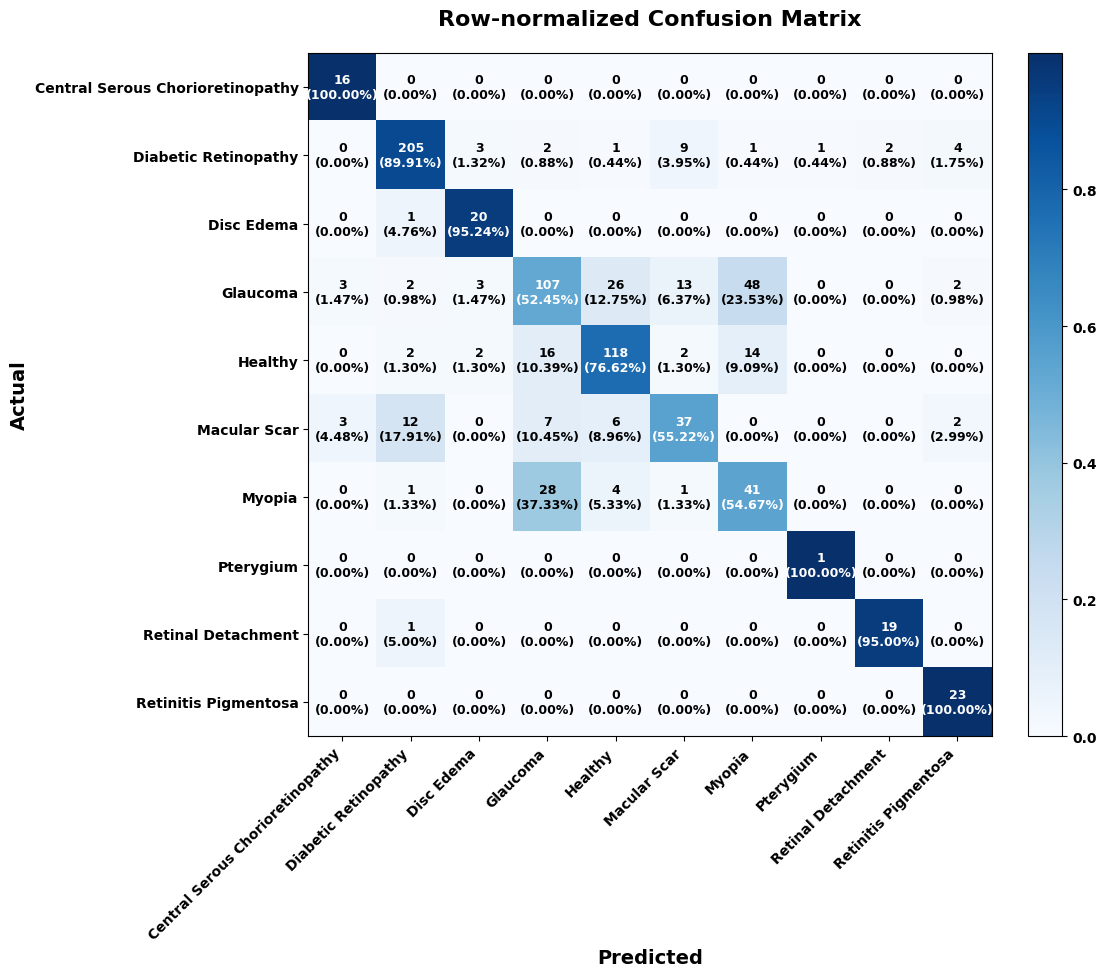

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Row-normalized values
row_sums = cm.sum(axis=1, keepdims=True)
row_perc = cm / (row_sums + 1e-8)

fig, ax = plt.subplots(figsize=(12, 10))  # ✅ bigger figure

im = ax.imshow(row_perc, cmap="Blues")

# ✅ ticks
ax.set_xticks(np.arange(N))
ax.set_yticks(np.arange(N))

ax.set_xticklabels(class_names, fontsize=10, rotation=45, ha="right")
ax.set_yticklabels(class_names, fontsize=10)

ax.set_xlabel("Predicted", fontsize=14, fontweight="bold")
ax.set_ylabel("Actual", fontsize=14, fontweight="bold")
ax.set_title("Row-normalized Confusion Matrix", fontsize=16, fontweight="bold", pad=20)

# ✅ add text inside cells
for i in range(N):
    for j in range(N):
        count = cm[i, j]
        perc = row_perc[i, j] * 100
        ax.text(
            j, i,
            f"{count}\n({perc:.2f}%)",
            ha="center", va="center",
            fontsize=9,
            fontweight="bold",
            color="white" if row_perc[i, j] > 0.5 else "black"
        )

# ✅ colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()

# ✅ save at 600 DPI
plt.savefig("confusion_matrix_600dpi.png", dpi=600, bbox_inches="tight")
plt.show()
